In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
  from google.colab import drive
  drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/emotion/tweet_emotions.csv',
    usecols=['content', 'sentiment'],
    dtype={'content': 'string', 'sentiment': 'category'}
)

In [ ]:
df

,sentiment,content
0,empty,@tiffanylue i know i was listenin to bad habi...
1,sadness,Layin n bed with a headache ughhhh...waitin o...
2,sadness,Funeral ceremony...gloomy friday...
3,enthusiasm,wants to hang out with friends SOON!
4,neutral,@dannycastillo We want to trade with someone w...
...,...,...
39995,neutral,@JohnLloydTaylor
39996,love,Happy Mothers Day All my love
39997,love,Happy Mother's Day to all the mommies out ther...
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


In [ ]:
df = df.rename(columns={'content': 'tweet', 'sentiment': 'label'})

In [ ]:
labels = ['sadness', 'neutral', 'happiness', 'worry', 'love']
df = df.query('label in @labels')

In [ ]:
df

,label,tweet
1,sadness,Layin n bed with a headache ughhhh...waitin o...
2,sadness,Funeral ceremony...gloomy friday...
4,neutral,@dannycastillo We want to trade with someone w...
5,worry,Re-pinging @ghostridah14: why didn't you go to...
6,sadness,"I should be sleep, but im not! thinking about ..."
...,...,...
39995,neutral,@JohnLloydTaylor
39996,love,Happy Mothers Day All my love
39997,love,Happy Mother's Day to all the mommies out ther...
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


In [ ]:

df.label = df.label.cat.remove_unused_categories()

/tmp/ipython-input-1602486799.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.label = df.label.cat.remove_unused_categories()


In [ ]:
# Rename labels
df['label'] = df['label'].replace('sadness', 'negative')
df['label'] = df['label'].replace('worry', 'negative')
df['label'] = df['label'].replace('happiness', 'positive')
df['label'] = df['label'].replace('love', 'positive')
data = df.dropna().reset_index(drop=True)

/tmp/ipython-input-3521309304.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['label'] = df['label'].replace('sadness', 'negative')
/tmp/ipython-input-3521309304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].replace('sadness', 'negative')
/tmp/ipython-input-3521309304.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser

In [ ]:
data_pos = data.query('label == "positive"')[:300]
data_neu = data.query('label == "neutral"')[:300]
data_neg = data.query('label == "negative"')[:300]

data_final = pd.concat([data_pos, data_neu, data_neg])

In [ ]:
data_final.reset_index(drop=True, inplace=True)

In [ ]:
data['label'].value_counts()


,count
label,
negative,13624
positive,9051
neutral,8638


<Axes: xlabel='label', ylabel='Count'>

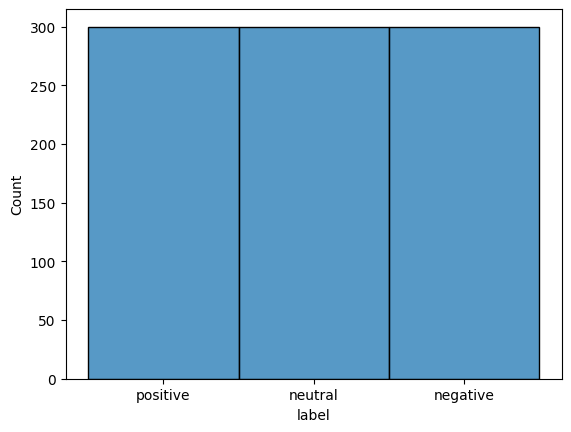

In [ ]:
sns.histplot(data_final, x='label')

In [ ]:
import keras
from transformers import pipeline

distilled_student_sentiment_classifier = pipeline(
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    tokenizer="lxyuan/distilbert-base-multilingual-cased-sentiments-student"
)

config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
distilled_student_sentiment_classifier("I love this movie and i would watch it again and again!")

[{'label': 'positive', 'score': 0.9731043577194214}]

In [ ]:
cardiffnlp_sentiment_classifier = pipeline(
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    tokenizer='cardiffnlp/twitter-roberta-base-sentiment-latest'
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
cardiffnlp_sentiment_classifier("I love this movie and i would watch it again and again!")

[{'label': 'positive', 'score': 0.9894440770149231}]

In [ ]:
finiteautomata_sentiment_classifier = pipeline(
    model='finiteautomata/bertweet-base-sentiment-analysis',
    tokenizer='finiteautomata/bertweet-base-sentiment-analysis'
)

config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/338 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Device set to use cuda:0


In [ ]:
finiteautomata_sentiment_classifier("I love this movie and i would watch it again and again!")

[{'label': 'POS', 'score': 0.9923557043075562}]

In [ ]:
import time

start_time = time.time()

i = 0

results = []

for index, row in data_final.iterrows():
    i += 1
    y_true = row["label"]
    X = row["tweet"]

    y_dict_1 = distilled_student_sentiment_classifier(X)[0]
    y_pred_1 = y_dict_1['label']
    y_pred_1_score = y_dict_1['score']

    y_dict_2 = cardiffnlp_sentiment_classifier(X)[0]
    y_pred_2 = y_dict_2['label']
    y_pred_2_score = y_dict_2['score']

    y_dict_3 = finiteautomata_sentiment_classifier(X)[0]
    y_pred_3 = y_dict_3['label']
    y_pred_3_score = y_dict_3['score']

    results.append([y_true, y_pred_1, y_pred_1_score, y_pred_2, y_pred_2_score, y_pred_3, y_pred_3_score])

    if i % 100 == 0:
        print(f'iteration {i}')
        print(f'{round(time.time() - start_time)} s')

    if i >= 1000:
        break

results_df = pd.DataFrame(results, columns=['y_true', 'y_1', 'y_1_score', 'y_2', 'y_2_score', 'y_3', 'y_3_score'])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


iteration 100
2 s
iteration 200
4 s
iteration 300
6 s
iteration 400
9 s
iteration 500
12 s
iteration 600
14 s
iteration 700
16 s
iteration 800
18 s
iteration 900
20 s


In [ ]:
results_df

,y_true,y_1,y_1_score,y_2,y_2_score,y_3,y_3_score
0,positive,positive,0.554133,neutral,0.820752,POS,0.642412
1,positive,positive,0.479782,positive,0.985042,POS,0.992602
2,positive,positive,0.921758,positive,0.972440,POS,0.988596
3,positive,positive,0.555006,positive,0.982593,POS,0.992163
4,positive,negative,0.501767,positive,0.959946,POS,0.992228
...,...,...,...,...,...,...,...
895,negative,negative,0.466855,negative,0.912664,NEG,0.953239
896,negative,negative,0.398658,negative,0.638685,NEG,0.748460
897,negative,negative,0.920928,negative,0.898470,NEG,0.937973
898,negative,negative,0.638051,negative,0.906062,NEG,0.945997


In [ ]:
results_df['y_3'] = results_df['y_3'].replace('NEG', 'negative')
results_df['y_3'] = results_df['y_3'].replace('NEU', 'neutral')
results_df['y_3'] = results_df['y_3'].replace('POS', 'positive')

0.4822222222222222


<Axes: xlabel='y_true', ylabel='Count'>

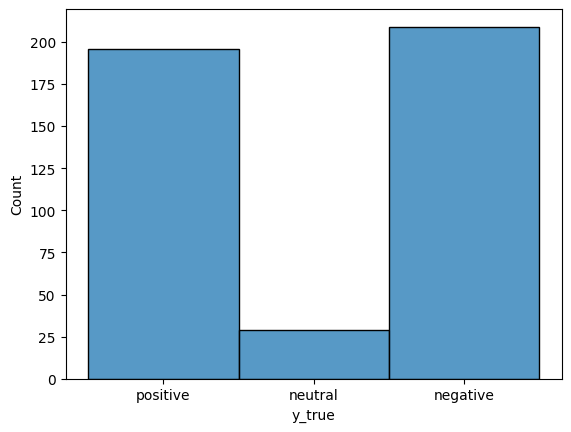

In [ ]:
correct_1 = results_df.query('y_true == y_1')
print(len(correct_1)/len(results_df))
sns.histplot(correct_1, x='y_true')

In [ ]:
correct_1['y_true'].value_counts()


,count
y_true,
negative,209
positive,196
neutral,29


0.6077777777777778


<Axes: xlabel='y_true', ylabel='Count'>

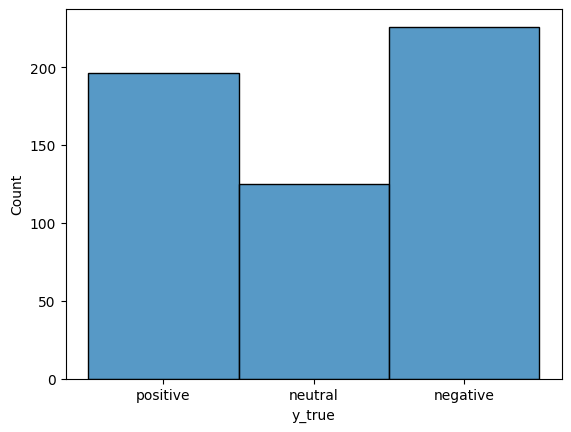

In [ ]:
correct_2 = results_df.query('y_true == y_2')
print(len(correct_2)/len(results_df))
sns.histplot(correct_2, x='y_true')

0.6011111111111112


<Axes: xlabel='y_true', ylabel='Count'>

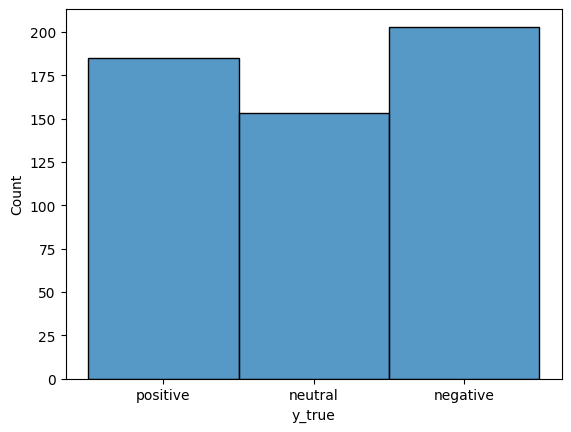

In [ ]:
correct_3 = results_df.query('y_true == y_3')
print(len(correct_3)/len(results_df))
sns.histplot(correct_3, x='y_true')

# **Hard** **Voting**

In [ ]:
correct = 0

for index, row in results_df.iterrows():
    y_true = row['y_true']

    #Voting Classifier Maximum voting
    y_preds = [row['y_1'], row['y_2'], row['y_3']]
    y_pred_vc = max(y_preds,key=y_preds.count)
    if y_pred_vc == y_true:
        correct += 1

print(correct/len(results_df))

0.59


## **SOFT VOTING**

In [ ]:
correct = 0

for index, row in results_df.iterrows():
    y_true = row['y_true']

    #Voting Classifier Highest confidence voting
    y_preds = [row['y_1'], row['y_2'], row['y_3']]
    y_preds_scores = [row['y_1_score'], row['y_2_score'], row['y_3_score']]
    y_pred_vc = y_preds[y_preds_scores.index(max(y_preds_scores))]
    if y_pred_vc == y_true:
        correct += 1

print(correct/len(results_df))

0.6166666666666667
